In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

print("✅ Libraries Imported")

✅ Libraries Imported


In [ ]:
path = "/content/drive/MyDrive/unified_multi_disease_dataset_MULTILABEL_ENHANCED.csv"
data = pd.read_csv(path)

print("✅ Dataset Loaded")
print("Shape:", data.shape)

data.columns = data.columns.str.strip()

data.rename(columns={
    "diabetes": "DIABETES",
    "heart_disease": "HEART_DISEASE",
    "parkinsons": "PARKINSONS"
}, inplace=True)

print("Columns:", list(data.columns)[:20])

✅ Dataset Loaded
Shape: (50000, 20)
Columns: ['age', 'sex', 'bmi', 'blood_pressure', 'glucose', 'cholesterol', 'heart_rate', 'tremor_score', 'voice_jitter', 'reaction_time', 'label', 'DIABETES', 'HEART_DISEASE', 'PARKINSONS', 'family_history', 'smoking', 'exercise_level', 'insulin', 'HbA1c', 'chest_pain']


In [ ]:
print("\n=========== 10 SAMPLE PATIENT RECORDS ===========")
display(data.sample(10, random_state=42))


=========== 10 SAMPLE PATIENT RECORDS ===========


,age,sex,bmi,blood_pressure,glucose,cholesterol,heart_rate,tremor_score,voice_jitter,reaction_time,label,DIABETES,HEART_DISEASE,PARKINSONS,family_history,smoking,exercise_level,insulin,HbA1c,chest_pain
33553,38.575630,-0.368476,21.250984,177.281014,168.190068,197.964523,88.860144,-0.125620,0.355712,0.598877,0,1,0,0,0,1,1,81.4,4.3,2
9427,37.296756,1.085009,20.745944,118.558302,182.052492,275.244219,85.134736,0.703174,-0.686605,0.964928,1,1,0,0,1,1,0,99.2,5.1,0
199,54.201892,0.280116,37.823082,166.207717,97.770609,135.492000,114.989720,0.018842,0.076629,0.861579,1,1,0,0,1,0,2,31.6,6.6,2
12447,43.344425,0.803524,35.891328,98.559621,122.215942,157.706355,62.048522,0.747173,0.506530,1.517306,1,1,0,0,1,0,1,70.5,7.0,0
39489,25.054757,-0.084672,30.324078,104.926993,173.349833,275.119858,66.636855,1.642460,-0.173068,0.040762,1,0,0,1,1,0,1,93.4,6.2,0
42724,22.276241,0.966940,22.157644,124.969266,167.250337,257.373802,74.031033,0.236951,0.186965,1.322256,0,0,0,1,1,0,0,80.3,5.0,0
10822,80.115482,-0.654315,37.994172,122.214889,116.053265,166.799378,50.998588,1.285967,0.006912,0.321790,0,0,1,0,1,1,2,111.9,6.8,0
49498,80.938321,0.762812,39.094566,107.982664,76.886407,177.703738,83.815902,1.344778,0.255516,-0.598827,1,0,0,1,0,0,1,76.2,4.9,2
4144,66.311717,1.386937,29.854898,177.922037,161.507553,220.276494,99.013707,1.093917,-0.299738,0.979874,0,1,0,0,1,1,1,57.8,7.0,2
36958,23.450596,1.029787,24.772924,93.884653,80.060840,223.394370,112.766242,0.575743,-0.192703,-0.370314,1,0,1,1,0,0,1,45.4,7.3,0


In [ ]:
X = data.drop(columns=["label"])
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Train/Test Split + Scaling Done")

✅ Train/Test Split + Scaling Done


In [ ]:
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

svm = SVC(kernel='rbf', C=10, gamma='scale')

nn = MLPClassifier(
    hidden_layer_sizes=(24,12),
    max_iter=100,
    alpha=0.008,
    early_stopping=True,
    random_state=42
)

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "Neural Network": nn
}

print("✅ Models Created")

✅ Models Created


In [ ]:
X_train_svm = X_train[:6000]
y_train_svm = y_train[:6000]

training_times = {}

for name, model in models.items():
    start = time.time()

    if name == "SVM":
        model.fit(X_train_svm, y_train_svm)
    else:
        model.fit(X_train, y_train)

    end = time.time()
    training_times[name] = round(end - start, 2)

print("\nTraining Time:")
for k, v in training_times.items():
    print(k, ":", v, "seconds")

print("✅ Models Trained")


Training Time:
Decision Tree : 1.01 seconds
Random Forest : 18.29 seconds
SVM : 10.81 seconds
Neural Network : 21.1 seconds
✅ Models Trained


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
pred_store = {}
accuracies = {}

print("\n=========== MODEL EVALUATION ===========")

for name, model in models.items():
    y_pred = model.predict(X_test)
    pred_store[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    print("\nModel:", name)
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, y_pred, digits=2))


=========== MODEL EVALUATION ===========

Model: Decision Tree
Accuracy: 0.8952
              precision    recall  f1-score   support

           0       0.94      0.82      0.87      4448
           1       0.87      0.96      0.91      5552

    accuracy                           0.90     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.90      0.89     10000


Model: Random Forest
Accuracy: 0.9852
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      4448
           1       1.00      0.98      0.99      5552

    accuracy                           0.99     10000
   macro avg       0.98      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Model: SVM
Accuracy: 0.7464
              precision    recall  f1-score   support

           0       0.72      0.70      0.71      4448
           1       0.76      0.79      0.77      5552

    accuracy                     

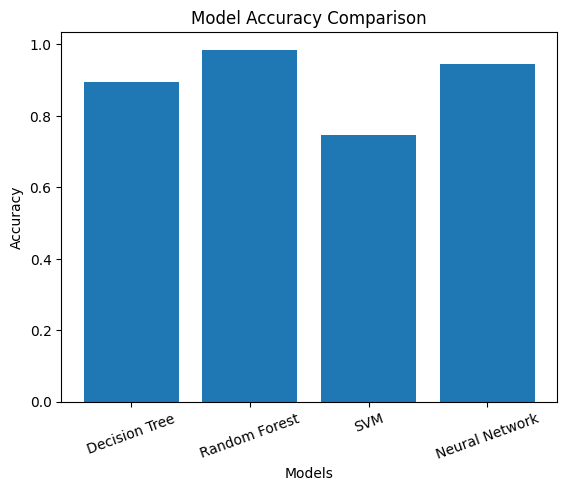

In [ ]:
plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()


=========== CONFUSION MATRICES ===========


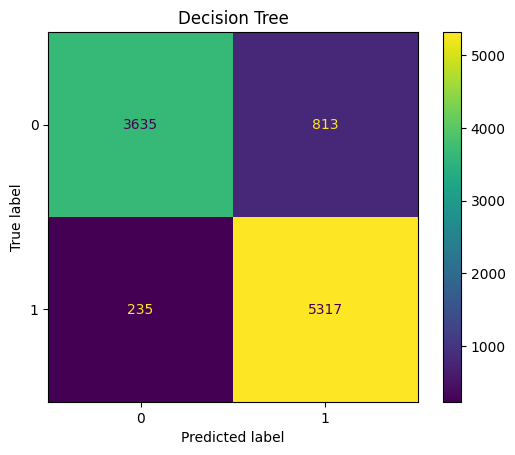

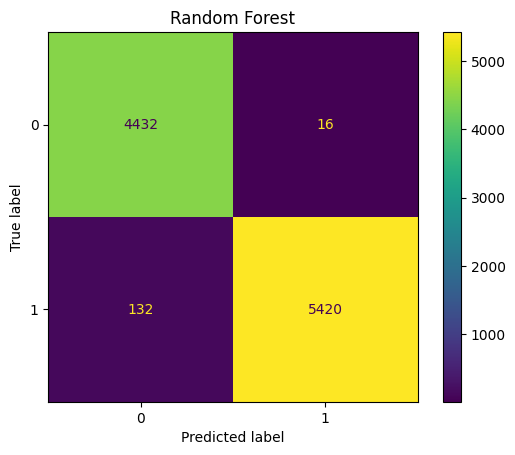

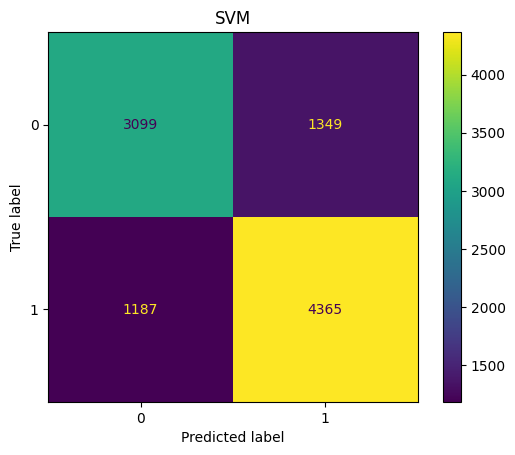

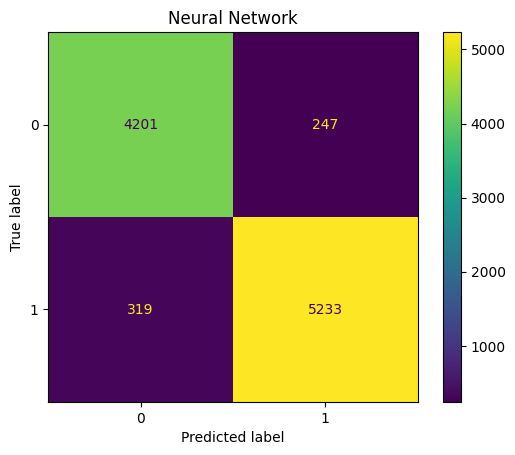

In [ ]:
print("\n=========== CONFUSION MATRICES ===========")

for name, y_pred in pred_store.items():
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(name)
    plt.show()

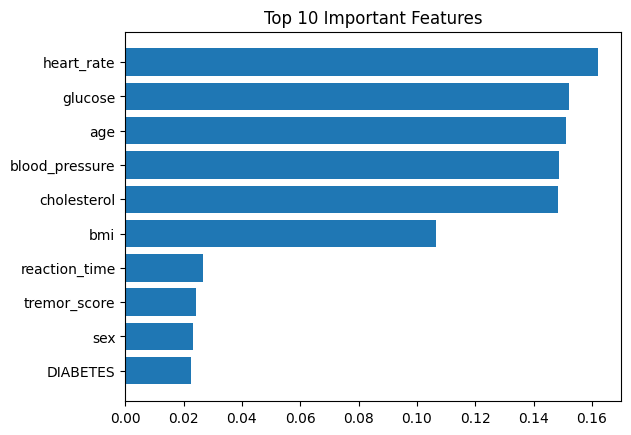

In [ ]:
importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({"Feature": features, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False).head(10)

plt.figure()
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
result_df = pd.DataFrame({
    "Model": list(accuracies.keys()),
    "Accuracy": list(accuracies.values())
})

print("\nModel Comparison:")
display(result_df)

best_model = max(accuracies, key=accuracies.get)
print("\nBest Model:", best_model, "| Accuracy:", round(accuracies[best_model], 4))


Model Comparison:


,Model,Accuracy
0,Decision Tree,0.8952
1,Random Forest,0.9852
2,SVM,0.7464
3,Neural Network,0.9434



Best Model: Random Forest | Accuracy: 0.9852


In [ ]:
cv_score = cross_val_score(rf, X_train, y_train, cv=5)
print("Cross Validation Accuracy:", round(cv_score.mean(), 4))

Cross Validation Accuracy: 0.9852


In [ ]:
df = data.copy()

X_multi = df.drop(columns=['DIABETES','HEART_DISEASE','PARKINSONS','label'])
y_multi = df[['DIABETES','HEART_DISEASE','PARKINSONS']]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

scaler_m = StandardScaler()
X_train_m = scaler_m.fit_transform(X_train_m)
X_test_m = scaler_m.transform(X_test_m)

print("✅ Multi-disease data ready")

✅ Multi-disease data ready


In [ ]:
multi_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

multi_model.fit(X_train_m, y_train_m)
print("✅ Multi-disease model trained")

✅ Multi-disease model trained



=========== ROC CURVE ===========


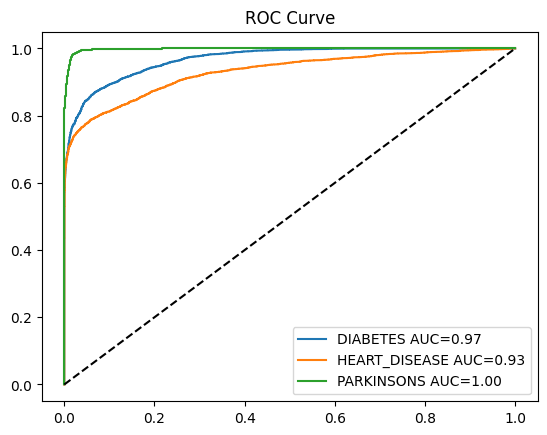

In [ ]:
print("\n=========== ROC CURVE ===========")

diseases = ['DIABETES','HEART_DISEASE','PARKINSONS']
probs = multi_model.predict_proba(X_test_m)

plt.figure()

for i, disease in enumerate(diseases):
    y_prob = probs[i][:, 1]
    fpr, tpr, _ = roc_curve(y_test_m.iloc[:, i], y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{disease} AUC={roc_auc:.2f}")

plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.title("ROC Curve")
plt.show()

In [ ]:
df_yes = df[(df["DIABETES"] + df["HEART_DISEASE"] + df["PARKINSONS"]) >= 1]
test_patients = df_yes.sample(10) if len(df_yes) >= 10 else df.sample(10)

for i in range(len(test_patients)):
    patient = test_patients.iloc[i:i+1]

    features = patient.drop(columns=['DIABETES','HEART_DISEASE','PARKINSONS','label'])
    features_scaled = scaler_m.transform(features)

    pred = multi_model.predict(features_scaled)[0]
    result = ["YES" if p == 1 else "NO" for p in pred]

    print("\nPatient", i+1)
    print("---- Disease Prediction Result ----")
    print("DIABETES :", result[0])
    print("HEART_DISEASE :", result[1])
    print("PARKINSONS :", result[2])


Patient 1
---- Disease Prediction Result ----
DIABETES : NO
HEART_DISEASE : YES
PARKINSONS : NO

Patient 2
---- Disease Prediction Result ----
DIABETES : NO
HEART_DISEASE : NO
PARKINSONS : YES

Patient 3
---- Disease Prediction Result ----
DIABETES : NO
HEART_DISEASE : NO
PARKINSONS : YES

Patient 4
---- Disease Prediction Result ----
DIABETES : YES
HEART_DISEASE : NO
PARKINSONS : NO

Patient 5
---- Disease Prediction Result ----
DIABETES : YES
HEART_DISEASE : NO
PARKINSONS : NO

Patient 6
---- Disease Prediction Result ----
DIABETES : NO
HEART_DISEASE : NO
PARKINSONS : NO

Patient 7
---- Disease Prediction Result ----
DIABETES : YES
HEART_DISEASE : NO
PARKINSONS : NO

Patient 8
---- Disease Prediction Result ----
DIABETES : NO
HEART_DISEASE : NO
PARKINSONS : YES

Patient 9
---- Disease Prediction Result ----
DIABETES : NO
HEART_DISEASE : YES
PARKINSONS : NO

Patient 10
---- Disease Prediction Result ----
DIABETES : YES
HEART_DISEASE : NO
PARKINSONS : NO


In [ ]:
patient = df.sample(1)

features = patient.drop(columns=['DIABETES','HEART_DISEASE','PARKINSONS','label'])
features_scaled = scaler_m.transform(features)

pred = multi_model.predict(features_scaled)[0]
result = ["YES" if p == 1 else "NO" for p in pred]

print("\n---- Disease Prediction Result ----")
print("DIABETES :", result[0])
print("HEART_DISEASE :", result[1])
print("PARKINSONS :", result[2])


---- Disease Prediction Result ----
DIABETES : YES
HEART_DISEASE : NO
PARKINSONS : NO
